The p-value (1.68 × 10⁻⁵⁵) is far below 0.05, indicating a statistically significant difference between Group A and Group B.
This means the higher engagement in the personalized message group is not due to random chance.
Therefore, personalized messaging significantly improves patient engagement and should be scaled.

In [45]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['ab_group'], df['simulated_engagement'])

chi2, p, dof, expected = chi2_contingency(contingency_table)

p

np.float64(1.687890966843922e-55)

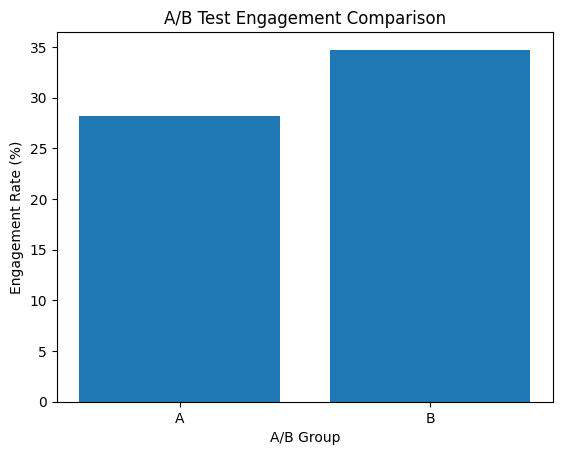

In [44]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(ab_results['ab_group'], ab_results['engagement_rate_%'])
plt.xlabel("A/B Group")
plt.ylabel("Engagement Rate (%)")
plt.title("A/B Test Engagement Comparison")
plt.show()

In [43]:
ab_results['engagement_rate_%'] = ab_results['simulated_engagement'] * 100
ab_results

,ab_group,simulated_engagement,engagement_rate_%
0,A,0.281623,28.162272
1,B,0.347355,34.735513


In [41]:
ab_results = df.groupby('ab_group')['simulated_engagement'].mean().reset_index()
ab_results

,ab_group,simulated_engagement
0,A,0.281623
1,B,0.347355


In [40]:
df['simulated_engagement'] = np.where(
    df['ab_group'] == 'A',
    np.random.binomial(1, 0.28, len(df)),
    np.random.binomial(1, 0.35, len(df))
)

In [38]:
import numpy as np

# Randomly assign patients to A or B
np.random.seed(42)

df['ab_group'] = np.random.choice(['A', 'B'], size=len(df))
df['ab_group'].value_counts()

,count
ab_group,
A,24650
B,24557


The ROC curve lies close to the diagonal line, indicating the model has little to no ability to distinguish between engaged and non-engaged patients.
This suggests the model is performing nearly like random guessing, with very poor predictive power for the positive class.


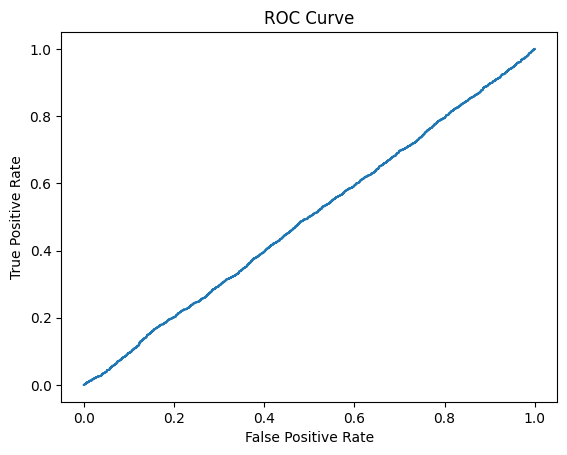

In [ ]:
#Optional: ROC Curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
#AUC Score
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
auc

np.float64(0.49624004910055847)

The classification report shows that the model performs well only for class 0 (non-engaged) with 100% recall, meaning it correctly identified all non-engaged patients.
However, for class 1 (engaged), precision and recall are both 0, indicating the model failed to predict any engaged patients.
Although overall accuracy is 70%, the model is biased toward the majority class and does not effectively detect positive engagement cases.
This confirms a class imbalance issue, requiring techniques such as class weighting, resampling, or threshold adjustment to improve performance.

In [ ]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      1.00      0.82      6898
           1       0.00      0.00      0.00      2944

    accuracy                           0.70      9842
   macro avg       0.35      0.50      0.41      9842
weighted avg       0.49      0.70      0.58      9842



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[6898,    0],
       [2944,    0]])

The model achieved an accuracy of 70.09%, meaning it correctly predicted engagement status for about 70% of the patients.
However, since the confusion matrix shows that all predictions were non-engaged, this accuracy is misleading and likely driven by class imbalance rather than true predictive performance.

In [ ]:
#Model Evaluation
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.700873806136964

In [ ]:

#Make Predictions

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [ ]:
#Build Logistic Regression Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
#Feature Scaling (Important for Logistic Regression)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Logistic Regression Model

In [ ]:
#Logistic Regression Model
# Define features (X) and target (y)

X = df[['age',
        'gender',
        'chronic_condition',
        'telehealth_visits_last_6m',
        'days_since_last_visit',
        'risk_score_normalized']]

y = df['engaged_outreach']

🏁 What You Achieved in EDA

✔ Identified risk patterns by age
✔ Validated chronic condition impact
✔ Analyzed telehealth usage distribution
✔ Measured outreach effectiveness

The average risk score is nearly the same for both engaged and non-engaged patients. Non-engaged patients have an average risk of 2.50, while engaged patients have 2.49. This indicates that engagement is not strongly influenced by risk level alone. Additional factors such as communication strategy or personalization may impact engagement behavior.

In [ ]:
engagement_by_risk = df.groupby('engaged_outreach')['risk_score'].mean().reset_index()
engagement_by_risk

,engaged_outreach,risk_score
0,0,2.502505
1,1,2.494801


which  means 29.8% of patients responded to outreach efforts.
  

In [ ]:
engagement_rate * 100

np.float64(29.822992663645415)

In [ ]:
#Engagement Rate
engagement_rate = df['engaged_outreach'].mean()
engagement_rate

np.float64(0.29822992663645415)

The bar chart shows that patients with chronic conditions have a significantly higher average risk score compared to those without chronic conditions.
Patients without chronic conditions have an average risk of 1.91, while those with chronic conditions have a much higher average risk of 3.38.
This confirms that chronic illness is a major driver of health risk prediction.
It supports prioritizing chronic patients for proactive care and targeted outreach.

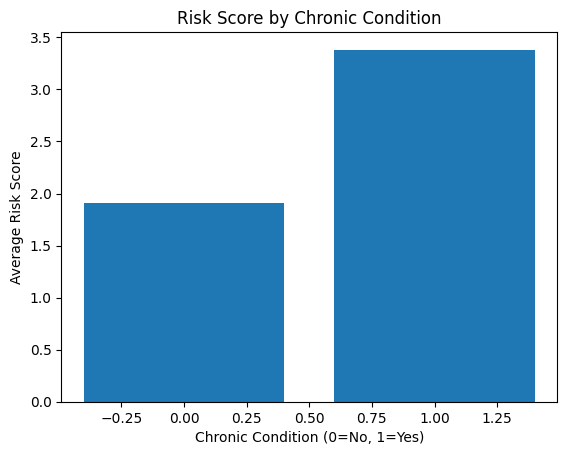

In [ ]:
plt.figure()
plt.bar(risk_chronic['chronic_condition'], risk_chronic['risk_score'])
plt.xlabel("Chronic Condition (0=No, 1=Yes)")
plt.ylabel("Average Risk Score")
plt.title("Risk Score by Chronic Condition")
plt.show()

In [ ]:
#Telehealth Usage Patterns
risk_chronic = df.groupby('chronic_condition')['risk_score'].mean().reset_index()
risk_chronic

,chronic_condition,risk_score
0,0,1.912664
1,1,3.381283


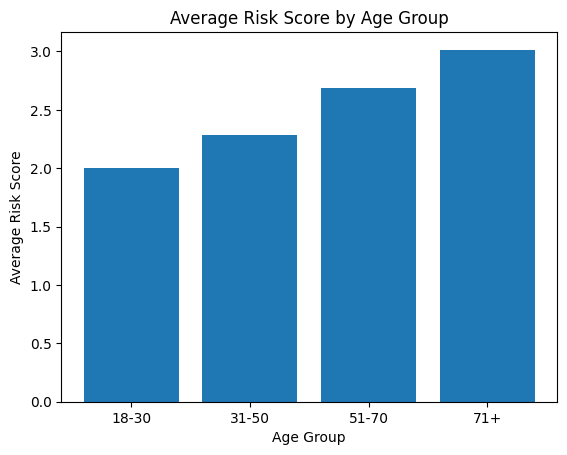

In [ ]:
#visualization
#Chronic Condition vs Risk
import matplotlib.pyplot as plt

plt.figure()
plt.bar(avg_risk_age['age_group'], avg_risk_age['risk_score'])
plt.xlabel("Age Group")
plt.ylabel("Average Risk Score")
plt.title("Average Risk Score by Age Group")
plt.show()

The bar chart shows that average risk score increases with age.
Patients aged 18–30 have the lowest risk, while those 71+ have the highest.
This indicates that age is a strong contributor to predicted health risk.
It helps prioritize older patients for monitoring and intervention.

In [ ]:
#Calculate Average Risk by Age Group
avg_risk_age = df.groupby('age_group')['risk_score'].mean().reset_index()
avg_risk_age

/tmp/ipython-input-4200417522.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_risk_age = df.groupby('age_group')['risk_score'].mean().reset_index()


,age_group,risk_score
0,18-30,1.999819
1,31-50,2.286866
2,51-70,2.687119
3,71+,3.014752


In [ ]:
#Exploratory Data Analysis
#Average Risk by Age Group
# Create age groups
df['age_group'] = pd.cut(df['age'],
                         bins=[18, 30, 50, 70, 90],
                         labels=['18-30', '31-50', '51-70', '71+'])

df.head()

,patient_id,age,gender,chronic_condition,telehealth_visits_last_6m,days_since_last_visit,engaged_outreach,risk_score,risk_score_normalized,age_group
0,100000,69,1,1,2,54,1,2.63,0.515625,51-70
1,100001,32,1,0,4,358,1,2.81,0.539062,31-50
2,100002,78,1,0,3,163,1,2.15,0.453125,71+
3,100003,38,0,0,3,161,0,2.76,0.532552,31-50
5,100005,20,0,0,0,166,0,2.42,0.488281,18-30


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 49207 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 49207 non-null  int64  
 1   age                        49207 non-null  int64  
 2   gender                     49207 non-null  object 
 3   chronic_condition          49207 non-null  int64  
 4   telehealth_visits_last_6m  49207 non-null  int64  
 5   days_since_last_visit      49207 non-null  int64  
 6   engaged_outreach           49207 non-null  int64  
 7   risk_score                 49207 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 3.4+ MB


,0
patient_id,0
age,0
gender,0
chronic_condition,0
telehealth_visits_last_6m,0
days_since_last_visit,0
engaged_outreach,0
risk_score,0


In [ ]:
# Re-load the original dataset
import pandas as pd

file_path = '/content/drive/MyDrive/healthcare_telemedicine_project_data.csv'
df = pd.read_csv(file_path)

# 1. Clean and encode the 'gender' column immediately after loading
df['gender'] = df['gender'].str.strip().str.lower()
df['gender'] = df['gender'].map({'male': 0, 'female': 1})

# 2. Apply age filtering
df = df[(df['age'] >= 18) & (df['age'] <= 90)]

# 3. Apply outlier removal
columns = ['risk_score',
           'telehealth_visits_last_6m',
           'days_since_last_visit']

print("Shape before removing outliers:", df.shape)

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

    print(f"{col} cleaned → Lower: {lower}, Upper: {upper}")

print("Shape after removing outliers:", df.shape)

# Display the head and info to verify the corrected DataFrame
display(df.head())
df.info()

Shape before removing outliers: (50000, 8)
risk_score cleaned → Lower: -1.3300000000000003, Upper: 6.3500000000000005
telehealth_visits_last_6m cleaned → Lower: -1.0, Upper: 7.0
days_since_last_visit cleaned → Lower: -178.0, Upper: 542.0
Shape after removing outliers: (49207, 8)


,patient_id,age,gender,chronic_condition,telehealth_visits_last_6m,days_since_last_visit,engaged_outreach,risk_score
0,100000,69,1,1,2,54,1,2.63
1,100001,32,1,0,4,358,1,2.81
2,100002,78,1,0,3,163,1,2.15
3,100003,38,0,0,3,161,0,2.76
5,100005,20,0,0,0,166,0,2.42


<class 'pandas.core.frame.DataFrame'>
Index: 49207 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 49207 non-null  int64  
 1   age                        49207 non-null  int64  
 2   gender                     49207 non-null  int64  
 3   chronic_condition          49207 non-null  int64  
 4   telehealth_visits_last_6m  49207 non-null  int64  
 5   days_since_last_visit      49207 non-null  int64  
 6   engaged_outreach           49207 non-null  int64  
 7   risk_score                 49207 non-null  float64
dtypes: float64(1), int64(7)
memory usage: 3.4 MB


In [ ]:
df[['risk_score', 'risk_score_normalized']].head()

,risk_score,risk_score_normalized
0,2.63,0.515625
1,2.81,0.539062
2,2.15,0.453125
3,2.76,0.532552
5,2.42,0.488281


In [ ]:
#Normalize Risk Score (Scaling)

#We will use Min-Max Scaling (0 to 1).

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['risk_score_normalized'] = scaler.fit_transform(df[['risk_score']])

There are only two values:

0 → Male

1 → Female

In [ ]:
df['gender'].unique()

array([1, 0])

**Encoding Categorical Variable (Gender)**

The gender column was converted from categorical values (Male, Female) to numeric format (0, 1) because most machine learning algorithms require numerical input features.

Machine learning models perform mathematical computations (distance calculation, gradient updates, matrix operations), which cannot be directly applied to text values.

In [ ]:
df['gender'].isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49207 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 49207 non-null  int64  
 1   age                        49207 non-null  int64  
 2   gender                     49207 non-null  int64  
 3   chronic_condition          49207 non-null  int64  
 4   telehealth_visits_last_6m  49207 non-null  int64  
 5   days_since_last_visit      49207 non-null  int64  
 6   engaged_outreach           49207 non-null  int64  
 7   risk_score                 49207 non-null  float64
 8   risk_score_normalized      49207 non-null  float64
dtypes: float64(2), int64(7)
memory usage: 3.8 MB


Outlier Removal Summary

Before applying the IQR method(Interquartile Range formula is simple: IQR = Q3 - Q1), the dataset contained 49,748 rows and 8 columns. After removing outliers from key numerical features (risk_score, telehealth_visits_last_6m, and days_since_last_visit), the dataset size reduced to 49,195 rows.

This means that 553 records were removed, which is approximately 1.1% of the total dataset.

Since less than 5% of the data was removed, this indicates that the dataset had very few extreme anomalies, and the removal process did not significantly impact overall data integrity.



In [ ]:
# List of columns to clean
columns = ['risk_score',
           'telehealth_visits_last_6m',
           'days_since_last_visit']

print("Shape before removing outliers:", df.shape)

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

    print(f"{col} cleaned → Lower: {lower}, Upper: {upper}")

print("Shape after removing outliers:", df.shape)

Shape before removing outliers: (50000, 8)
risk_score cleaned → Lower: -1.3300000000000003, Upper: 6.3500000000000005
telehealth_visits_last_6m cleaned → Lower: -1.0, Upper: 7.0
days_since_last_visit cleaned → Lower: -178.0, Upper: 542.0
Shape after removing outliers: (49207, 8)


**Age Filtering**

To ensure our analysis focuses on a relevant patient population, we've filtered the df DataFrame to include only individuals between the ages of 18 and 90 years old. This step helps to:

**Remove outliers:** Patients younger than 18 or older than 90 might represent special cases or data entry errors that could skew the analysis.

**Focus on the target demographic**: This age range is typically representative of the adult population where telemedicine interventions are most commonly applied and studied.

**Improve model accuracy (if applicable):** By narrowing the scope to a more consistent age group, any predictive models built on this data are likely to be more robust and accurate for this specific

In [ ]:
df = df[(df['age'] >= 18) & (df['age'] <= 90)]

**If duplicates found:**

df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

**If missing values exist:**

Option 1: Fill numeric columns with median

df.fillna(df.median(numeric_only=True), inplace=True)





Option 2: Drop missing rows

df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
patient_id,0
age,0
gender,0
chronic_condition,0
telehealth_visits_last_6m,0
days_since_last_visit,0
engaged_outreach,0
risk_score,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 50000 non-null  int64  
 1   age                        50000 non-null  int64  
 2   gender                     50000 non-null  object 
 3   chronic_condition          50000 non-null  int64  
 4   telehealth_visits_last_6m  50000 non-null  int64  
 5   days_since_last_visit      50000 non-null  int64  
 6   engaged_outreach           50000 non-null  int64  
 7   risk_score                 50000 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 3.1+ MB


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/healthcare_telemedicine_project_data.csv'
df = pd.read_csv(file_path)
display(df.head())

,patient_id,age,gender,chronic_condition,telehealth_visits_last_6m,days_since_last_visit,engaged_outreach,risk_score
0,100000,69,Female,1,2,54,1,2.63
1,100001,32,Female,0,4,358,1,2.81
2,100002,78,Female,0,3,163,1,2.15
3,100003,38,Male,0,3,161,0,2.76
4,100004,41,Male,1,8,267,1,4.91
